# Image Classification

tentative plan for this section:
- introduce neural networks, discuss some mathematical theory
- use neural networks for image recognition in the context of brick kilns

The main classification algorithm used for image-related tasks are deep learning-focused neural networks. Here, we will discuss neural networks on a very simplistic level; the actual architecture behind neural networks and their formation is very complex and cannot be fitted into a single section of a book.

## Neural Networks: The Basics

**Neural networks, in essence, take many different linear combinations of many features to form a new set of features. The network then takes these new features; a linear combination of them informs the final classification.**

Of course, this explanation of neural networks is highly reductionist and fails to capture almost all the details involved in its complex architecture. To better understand how neural networks work, we first need to go to their inspiration, the brain. 

### Neurons

Human brains (and the brains of many animals) are themselves a massive interconnected network of cells called *neurons*. These neurons are what relay signals between different parts of the brain, each portion of the brain handling different tasks. Neurons, at their core, have two states: resting, and excited. When resting, a neuron does not send any signals; when excited, a neuron sends a signal to another cell. Neurons can be excited through a number of different input stimuli; the neurons in your fingers are excited when you feel an object, while the neurons in your brain get excited when another neuron sends them a signal to be excited. 

The neuron of the brain formed the inspiration for the artificial neuron. Like a living neuron, an artifical neuron has two states: inactive, and active. Also like a living neuron, an artificial neuron receives a number of different inputs, but instead of sensations of chemicals, the inputs for an artificial neuron are numbers. Weights are applied to each of these inputs, and the sum of these is taken (i.e., a linear combination of these inputs). The sum then needs to be larger than a certain threshold to activate the artificial neuron. 

What does this look like, mathematically? We can display a simple example of this with two features. In the below example, the line forms a linear combination of the two features, plus an intercept (which counts as a feature that is always equal to 1).

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


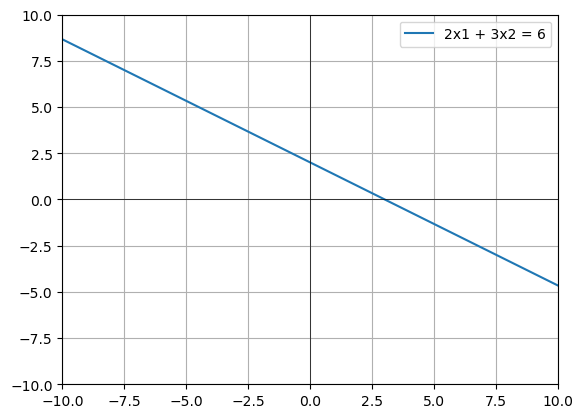

In [1]:
import matplotlib.pyplot as plt
import numpy as np

#make a plot with x1 horizontal and x2 vertical
#and the line 2x1 + 3x2 = 6
x1 = np.linspace(-10, 10, 400)
x2 = 2 - 2/3*x1

plt.plot(x1, x2, label='2x1 + 3x2 = 6')
plt.xlim(-10, 10)
plt.ylim(-10, 10)
plt.axhline(0, color='black', lw=0.5)
plt.axvline(0, color='black', lw=0.5)
plt.grid(True, which='both')
plt.legend()
plt.show()

Such a line divides this finite plane into two halves. (Even though the plane extends infinitely in theory, the line still divides it, but for practicality's sake, most features take on a finite range of values.) On one half of this plane, we have feature pairs where the linear combination of $2x_1 + 3x_2 > 6$; the other half has pairs where $2x_1 + 3x_2 < 6$. We can plot these as follows:

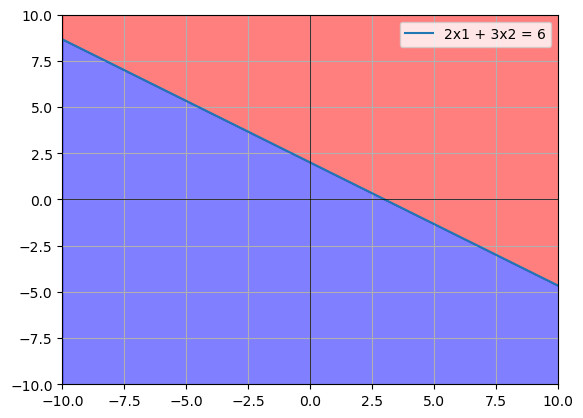

In [2]:
#same plot as above, but add shading to regions divided by the line
#for 2x1 + 3x2 > 6 in red and 2x1 + 3x2 < 6 in blue
x1 = np.linspace(-10, 10, 400)
x2 = 2 - 2/3*x1

plt.plot(x1, x2, label='2x1 + 3x2 = 6')
plt.fill_between(x1, x2, 10, color='red', alpha=0.5)
plt.fill_between(x1, x2, -10, color='blue', alpha=0.5)
plt.xlim(-10, 10)
plt.ylim(-10, 10)
plt.axhline(0, color='black', lw=0.5)
plt.axvline(0, color='black', lw=0.5)
plt.grid(True, which='both')
plt.legend()
plt.show()

Now if we say that the pairs in the red region are of one class and the pairs in the blue region are of another class, we can see how the classification of a single neuron can work. It simply takes a linear combination of all the features and checks if that combination is greater than its required threshold to classify it. 

## Classification with Brick Kiln Images

In [3]:
#helper functions
#this function is taken from the KilnNet repository directly
#the batch_generator function takes in features (data x) and labels (data y) and a batch size
#not sure at the moment what is being returned but will find out later
def batch_generator(data_X, data_y, batch_size):
    indexes = np.array(range(len(data_y)))
    n = len(indexes)
    while True:
        batch_start = 0
        batch_end = batch_size
        np.random.shuffle(indexes)
        while batch_start < n:
            index = []
            batch_y = []
            y = []
            index = indexes[batch_start:batch_end]
            batch_x = np.array([data_X[i] for i in index])
            batch_y = np.array([data_y[i] for i in index])
            yield batch_x, batch_y
            batch_start += batch_size
            batch_end += batch_size
            if (batch_end>len(data_y)):
                batch_end = len(data_y)

#this function is taken from the KilnNet repository directly
#the read_landUse function takes in a dataset path and an image type
#and returns the paths to the images and the labels
#in this context, the path is the path to the folder containing the images
#and the labels are the classes of the images, like agriculutre land, forest land, etc.
def read_landUse(dataset_path, im_type):
    import glob
    paths_X = []
    labels = []
    i = 0
    folders = sorted(os.listdir(dataset_path))
    for folder in folders:
        temp = sorted (glob.glob(os.path.join(dataset_path,folder+'/*'+im_type)))
        for k in range(len(temp)):
            labels.append (i)
        paths_X += temp
        i += 1

    if(len(paths_X)==0):
        print ('Dataset could not found. Please provide correct path.')
    return paths_X, labels

In [4]:
#set directory for brick kiln data
import os
os.chdir('/Users/jonathanzhu/Documents/ev work/kilns/')

import cv2
dataset_path = 'train'
paths, labels = read_landUse(dataset_path, '[(.png)(.jpg)]')
images = np.array([cv2.imread(image_name) for image_name in paths])


In [ ]:
#what version of tensorflow am I using?
import tensorflow as tf
print(tf.__version__)

In [1]:
model_name = 'VGG16_Jan2020'
num_classes = 14

from keras.utils import to_categorical
X_train = images
y_train = to_categorical(labels, num_classes)
#X, y = load_dataset(dataset_path)
print ('Size of dataset:', len(y_train))

In [10]:
dataset_path_val = 'val'
paths_val, labels_val = read_landUse(dataset_path_val, '[(.png)(.jpg)]')
X_val =  np.array([cv2.imread(image_name) for image_name in paths_val])
y_val = to_categorical(labels_val, num_classes)

NameError: name 'to_categorical' is not defined

In [ ]:
from sklearn.model_selection import train_test_split
X_val, X_test, y_val, y_test = train_test_split(X_val, y_val, test_size=0.2)
print(X_val.shape, X_test.shape, y_val.shape, y_test.shape)

In [ ]:
import pandas as pd

folders = os.listdir(dataset_path)
names, counts = [], []
for i, folder in enumerate(folders):
    dir_path = os.path.join(dataset_path, folder)
    images = os.listdir(dir_path)
    names.append(folder)
    counts.append(len(images))
    print(i, folder, len(images))
df = pd.DataFrame(data={'Name': names, 'Count': counts})
ax = df.plot(kind='bar', xticks=counts, grid=True, legend=False, figsize=(16,6))
ax.set_xlabel('Classes', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
plt.xticks(np.arange(len(names)), names, rotation=45, fontsize=15)
for i, v in enumerate(counts):
    ax.text(i-.18, v+15, str(v), color='blue', fontweight='bold')
plt.show()

In [ ]:
batch_size = 10
train_gen = batch_generator(X_train, y_train, batch_size)
val_gen = batch_generator(X_val, y_val, batch_size)
#test_gen = batch_generator(X_test, y_test, batch_size)

In [ ]:
#model loading and training
import keras
from keras.applications.vgg16 import VGG16
from keras.applications.vgg19 import VGG19
from keras.applications.resnet import ResNet50
from keras.applications.resnet import ResNet101
from keras.applications.resnet import ResNet152
from keras.applications.resnet_v2 import ResNet50V2
from keras.applications.resnet_v2 import ResNet101V2
from keras.applications.resnet_v2 import ResNet152V2
from keras.applications.inception_resnet_v2 import InceptionResNetV2
from keras.applications.inception_v3 import InceptionV3
from keras.applications.densenet import DenseNet121
from keras.applications.densenet import DenseNet169
from keras.applications.densenet import DenseNet201
from keras.activations import softmax, relu, sigmoid
from keras.optimizers.legacy import SGD

#uncomment to pick different models
input_shape=(256,256,3)
model= VGG16(include_top=True, weights=None, input_tensor=None, input_shape=input_shape, pooling=None, classes=num_classes)
#model= VGG19(include_top=True, weights=None, input_tensor=None, input_shape=input_shape, pooling=None, classes=num_classes)
#model= ResNet50(include_top=True, weights=None, input_tensor=None, input_shape=input_shape, pooling=None, classes=num_classes)
#= ResNet101(include_top=True, weights=None, input_tensor=None, input_shape=input_shape, pooling=None, classes=num_classes)
#model= ResNet152(include_top=True, weights=None, input_tensor=None, input_shape=input_shape, pooling=None, classes=num_classes)
#model= ResNet50V2(include_top=True, weights=None, input_tensor=None, input_shape=input_shape, pooling=None, classes=num_classes)
#model= ResNet101V2(include_top=True, weights=None, input_tensor=None, input_shape=input_shape, pooling=None, classes=num_classes)
# model= ResNet152V2(include_top=True, weights=None, input_tensor=None, input_shape=input_shape, pooling=None, classes=num_classes)
#model= InceptionResNetV2(include_top=True, weights=None, input_tensor=None, input_shape=input_shape, pooling=None, classes=num_classes)
#model= InceptionV3(include_top=True, weights=None, input_tensor=None, input_shape=input_shape, pooling=None, classes=num_classes)
#model= DenseNet121(include_top=True, weights=None, input_tensor=None, input_shape=input_shape, pooling=None, classes=num_classes)
#model= DenseNet169(include_top=True, weights=None, input_tensor=None, input_shape=input_shape, pooling=None, classes=num_classes)
#model= DenseNet201(include_top=True, weights=None, input_tensor=None, input_shape=input_shape, pooling=None, classes=num_classes)
#model =InceptionResNetV2(include_top=True, weights=None, input_tensor=None, input_shape=input_shape, pooling=None, classes=num_classes)
#model = resNet(input_shape, num_classes, model_type='resnet_152')
#model.load_weights('WEIGHTS/'+model_name+'.h5')

### model_vgg16.layers[-1].activation = relu

### idx_of_layer_to_change = -1
#model.layers[idx_of_layer_to_change].activation = activations.softmax
#model = utils.apply_modifications(model)

#model_vgg16.layers[-1].activation = relu
# # FINE TUNING HERE
# top_model = Sequential()
# top_model.add(Dense(input_shape=model.layers[-2].output_shape, units=num_classes, rnel
# kernel_initializer="he_normal", activation="softmax"))

# model.layers.pop()
# model.outputs = [model.layers[-1].output]
# model.layers[-1].outbound_nodes = []

# model = Model(inputs=model.inputs, outputs=top_model(model.outputs[0]))
# # for layer in model.layers[:-1]:
# #     layer.trainable = False
#model.load_weights('WEIGHTS/'+model_name+'.h5')

model.summary()
sgd = SGD(lr=0.01, decay=1e-6, momentum=0.9, nesterov=True)
model.compile(loss='categorical_crossentropy', optimizer=sgd, metrics=['accuracy'])
# plot_model(model, to_file='model.png')